# 6.4 DIEN 兴趣演化排序

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

当兴趣从旧主题转向新主题时，怎样区分“出现过什么”和“现在更想要什么”？

## Setup

本 Notebook 的默认真实数据是 **Amazon Reviews Electronics 5-core：DIN/DIEN 公开复现实验数据**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [Zhou et al., 2019, DIEN](https://arxiv.org/abs/1809.03672)

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "amazon-electronics"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'amazon-electronics', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': True, 'cuda_device': 'NVIDIA RTX 6000 Ada Generation'}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 当兴趣从旧主题转向新主题时，怎样区分“出现过什么”和“现在更想要什么”？

**阅读约定：** 通用数学通过 3.0 基础课程链接回看；本页只详细推导论文引入或改造的数学。第一次阅读先追踪输入、输出和形状，再看梯度。

## Paper & Context

DIEN（AAAI 2019，同一团队）认为 DIN 把行为直接当作兴趣、又忽略次序：真实兴趣藏在行为背后且随时间演化。它用 GRU 抽取逐时刻兴趣状态，以辅助下一行为损失给每步监督，再用目标感知的 AUGRU 控制状态演化。它比 DIN 重得多：收益依赖严格时间顺序和高质量负序列；线上要靠 kernel 融合、batching 与 Rocket Launching 压缩（GRU 隐状态 108→32 维）才把延迟从 38.2 ms 压到 6.6 ms。

**来源：** [Zhou et al., 2019, DIEN](https://arxiv.org/abs/1809.03672)

### 原文实验设计与关键结论

Table 2（公开集各重复 5 次）：Amazon Electronics DIEN AUC 0.7792±0.00243（DIN 0.7603、BaseModel 0.7435），Books 0.8453±0.00476（DIN 0.7880）。Table 3（工业数据，70 亿样本、历史截断 50）：DIEN 0.6541（DIN 0.6428、BaseModel 0.6350）。Table 4 消融：AUGRU 优于 AIGRU/AGRU；辅助损失在公开集贡献最大、工业集收益变小。Table 5 在线 A/B（2018-06-07~07-12，淘宝展示广告）：相对 BaseModel，DIEN CTR +20.7%、eCPM +17.1%、PPC −3.0%（DIN 为 +8.9%/+6.7%/−2.0%）。服务侧 GRU 隐状态 108→32 维，延迟 38.2→6.6 ms。以上均为论文系统口径，教程结果另行报告。

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Reproduction Contract

**正式数据：** Amazon Reviews Electronics 5-core  
**资源 ID：** `amazon-electronics-5core`  
**切分：** paper-compatible chronological negative sampling  
**指标：** AUC, LogLoss  
**与论文比较边界：** online CTR/eCPM values are not reproducible from public data

`full` 只有在运行输出证明数据、切分、候选集、模型配置与指标均对齐时，才可能进入论文数值比较；它不是把教学适配器自动变成论文复现的开关。`smoke` 只做张量、损失和推理链路回归。

## Model Structure & Formula Walkthrough

![Figure 1 · DIEN structure](/static/paper-figures/dien.webp)

> **论文原图节选** · Figure 1 · DIEN structure · PDF p.4。下图直接截取自原文，用于对照下方公式与代码。

### 关键模块

- **GRU 兴趣抽取层**：用 GRU 按时间更新隐状态 $h_t$，并加入辅助损失让 $h_t$ 能预测下一次真实行为，使每个时间步都有监督。
- **AUGRU 兴趣演化层**：用候选注意力 $a_t$ 缩放 GRU 的更新门：与候选无关的历史几乎不改变状态，相关历史才被写入。
- **主任务 CTR**：最后状态与用户/上下文特征拼接经 MLP 预测点击，总损失 = 主 BCE + $\alpha\cdot$ 辅助 BCE。

### 结构：GRU 抽取兴趣，AUGRU 按候选演化

GRU 是带两个『门』的递推网络，每个门都是 0～1 之间的数（Sigmoid 输出）。重置门 $r_t$ 决定计算候选新状态时保留多少旧记忆，更新门 $z_t$ 决定最终把多少新状态写进记忆：

$$r_t=\sigma(W_re_t+U_rh_{t-1}),\quad z_t=\sigma(W_ze_t+U_zh_{t-1}),$$
$$\tilde h_t=\tanh(W_he_t+U_h(r_t\odot h_{t-1})),\quad h_t=(1-z_t)\odot h_{t-1}+z_t\odot\tilde h_t.$$

其中 $e_t$ 是第 $t$ 步行为的 embedding，$h_{t-1}$ 是上一步记忆，$\odot$ 是逐维相乘，$W,U$ 是可学习权重。手算一步：设 $h_{t-1}=(0.8,0.2)$，当前行为算出 $z_t=0.25$、$\tilde h_t=(0.1,0.9)$，则

$$h_t=0.75\times(0.8,0.2)+0.25\times(0.1,0.9)=(0.625,0.325),$$

记忆向新兴趣方向挪了 25%。若某步 $z_t\approx0$，状态几乎不变——『门』的意义就是让网络自己学会哪一步该忘、哪一步该写。

辅助损失解决『中间状态没人教』的问题：主损失只看最后一次点击，长序列中第 $t$ 步的 $h_t$ 得不到监督。论文让每一步用 $h_t$ 区分下一次真实行为 $e_{t+1}^+$ 与负采样行为 $e_{t+1}^-$，即 $L_{aux}=-\sum_t[\log\sigma(h_t^\top e_{t+1}^+)+\log(1-\sigma(h_t^\top e_{t+1}^-))]$，总损失 $L=L_{target}+\alpha\cdot L_{aux}$（公开集实验 $\alpha=1$）。

AUGRU 再把 DIN 的候选注意力嵌进更新门：先对每步算与候选的相关分 $a_t$（softmax，和为 1），再缩放更新门 $\tilde z_t=a_t\,z_t$。于是与候选无关的历史 $a_t\approx0\Rightarrow\tilde z_t\approx0$，状态几乎不被改写，兴趣漂移被抑制；相关历史则正常参与演化。同样的历史集合换一种排列会得到不同的 $h_t$ 序列——这正是 DIEN 比 DIN 多出的『次序』能力。

### 公式到代码

`run_dien` 显式构造正历史、负历史和 mask；Torch-RecHub DIEN 同时返回主任务预测与辅助损失，训练代码展示两者如何相加。

阅读源码时按“张量形状 → 前向计算 → score → loss → metric”五步追踪，不需要一次读完整个工程文件。

## Math by Hand

### 通用先修（先回看 3.0 基础课程）

- [序列与时间泄漏](/notebooks/3_2_data_ml_basics#split-leakage)
- [逐元素运算](/notebooks/3_3_linear_algebra#elementwise-dot)
- [函数复合与激活](/notebooks/3_4_calculus#functions)
- [链式求导与反向传播](/notebooks/3_4_calculus#chain-rule)

### 本论文新增数学（本节详细推导）

GRU 兴趣抽取、逐步辅助损失，以及用候选注意力缩放更新门的 AUGRU。

GRU 是带记忆的递推函数 $h_t=\mathrm{GRU}(e_t,h_{t-1})$：同样的集合换一种顺序，末状态就不同。辅助损失要求 $h_t$ 更像下一次真实行为、远离负样本；AUGRU 用候选相关权重控制每步写入多少。下面的代码用 $\alpha=0.65$ 的指数递推模拟这种记忆：四个事件『旧、旧、新、新』演完后新兴趣分量约 $0.58$，顺序反过来只剩约 $0.24$——次序本身就是信息。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

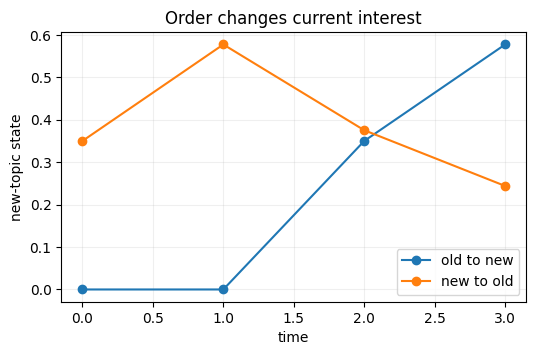

In [2]:
import numpy as np, matplotlib.pyplot as plt
alpha=.65
def evolve(sequence):
    state=np.zeros(2); path=[]
    for event in sequence:
        state=alpha*state+(1-alpha)*event; path.append(state.copy())
    return np.array(path)
old=np.array([1.,0.]); new=np.array([0.,1.]); paths=[evolve([old,old,new,new]),evolve([new,new,old,old])]
fig,ax=plt.subplots(figsize=(6,3.5)); ax.plot(paths[0][:,1],marker='o',label='old to new'); ax.plot(paths[1][:,1],marker='o',label='new to old')
ax.set(title='Order changes current interest',xlabel='time',ylabel='new-topic state'); ax.legend(); ax.grid(alpha=.2); plt.show()

## Data

### 权威 full 协议（效果验收目标）

**正式数据：** Amazon Reviews Electronics 5-core  
**资源 ID：** `amazon-electronics-5core`  
**切分：** paper-compatible chronological negative sampling  
**指标：** AUC, LogLoss  
**与论文比较边界：** online CTR/eCPM values are not reproducible from public data

### smoke 教学适配器（默认 runner 实际读取）

KuaiRand-Pure 的真实时间序列教学子集：点击视频进入正序列，已曝光未点击视频进入 `negative_history`；padding=0，未来曝光不进入历史。这里的负序列是“已曝光未点击”，不是从未曝光物品。

下方运行结果打印的 provenance 才是本次执行事实；若资源、统计或切分与 full 协议不一致，就必须标记为不可比较。

**防泄漏清单：**按时间切分；item 映射只表达已知目录，不读取测试标签；低评分或未点击负反馈均来自数据中的已观察行；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.ranking.DIEN，执行 GRU、auxiliary loss 与 AUGRU；full profile 需核对序列打包、负采样和线上顺序。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from importlib import import_module
from recsys_lab.runtime import print_progress, save_records

# 算法实现就在当前章节目录，不再通过公共模块隐藏。
chapter_train = import_module("chapter_code.6_4_dien.train")
run_dien = chapter_train.run_dien

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_dien))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_dien(epochs: int = 30, *, progress: ProgressCallback | None = None) -> dict:
    return _run_sequence_ranker("dien", epochs, progress=progress)



## Train & Inference

下一格固定 seed、构造数据、实例化模型、训练并进入推理路径。生成式章节在 CUDA 上执行完整评测；CPU 环境只验证缩小后的基本张量与约束链路。

In [4]:
result = run_dien(progress=print_progress)
REAL_DATASET = result['dataset']
assert REAL_DATASET['randomly_fabricated_rows'] == 0
print({'framework': result['framework'], 'dataset': result.get('dataset', {}),
       'device': result.get('device'), 'validation_mode': result.get('validation_mode')})
print('inference contract:', '严格按时间编码历史，候选控制 AUGRU 更新，最终状态进入 MLP；同时测 P99、吞吐和校准。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

[data_prepare] 0/1 加载并构造 DIEN 序列


[data_prepare] 1/1 rows=2600


[train] 0/30 starting


[train] 2/30 epoch 2/30 batch_loss=0.882846


[train] 4/30 epoch 4/30 batch_loss=0.834258


...

[baseline] 0/1 计算静态重合度基线


[baseline] 1/1 auc=0.501923


[evaluate] 0/1 计算 AUC 与 LogLoss


[evaluate] 1/1 auc=0.631255 logloss=0.537329


{'framework': 'torch_rechub.models.ranking.DIEN', 'dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '<ARTIFACT_ROOT>/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'profile': 'smoke', 'local_resource': '<ARTIFACT_ROOT>/data/kuairand-pure/standard_interactions.csv', 'rows_used': 29602, 'users_used': 96, 'items_used': 2200, 'time_min_utc': '2022-04-09T04:29:16+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0, 'rows': 2600, 'sequence_length': 20, 'label': 'observed KuaiRand is_click', 'negative_history': 'observed skipped impressions', 'time_ordered': True}, 'device': No

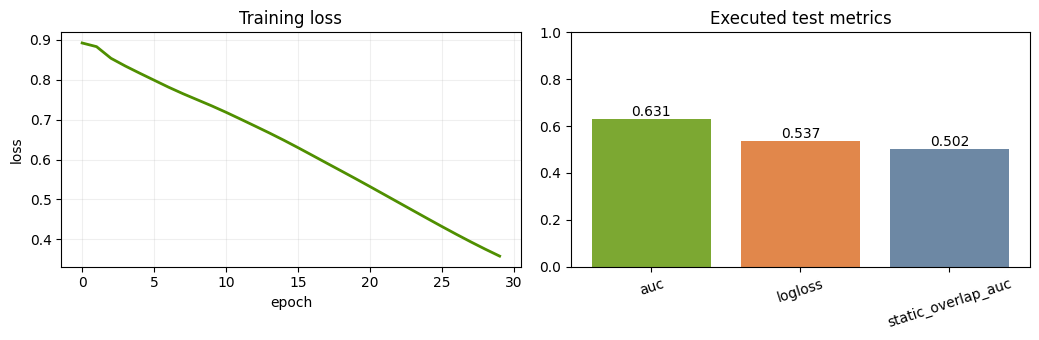

,value
auc,0.631255
logloss,0.537329
static_overlap_auc,0.501923


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'auc': result['auc'], 'logloss': result['logloss'], 'static_overlap_auc': result['static_overlap_auc']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

In [6]:
# 论文数字只能在数据、切分、候选和指标全部同口径时相减。
paper_protocol = json.loads('{"dataset": "Amazon Reviews Electronics 5-core", "resource": "amazon-electronics-5core", "split": "paper-compatible chronological negative sampling", "metrics": ["AUC", "LogLoss"], "paper_comparison": "online CTR/eCPM values are not reproducible from public data"}')
paper_targets = paper_protocol.get('paper_targets', {})
metric_key = {'HitRate@10':'paper_protocol_hr@10', 'NDCG@10':'paper_protocol_ndcg@10',
              'AUC':'auc', 'LogLoss':'logloss'}
dataset_name = result.get('dataset', {}).get('dataset', '')
dataset_aligned = paper_protocol.get('dataset', '').split(',')[0].casefold() in dataset_name.casefold()
comparison_eligible = PROFILE == 'full' and dataset_aligned
rows=[]
for paper_metric,target in paper_targets.items():
    result_key=metric_key.get(paper_metric)
    value=result.get(result_key) if result_key else None
    rows.append({'metric':paper_metric,'tutorial':value,'paper':target,
                 'absolute_gap':None if value is None or not comparison_eligible else float(value)-float(target),
                 'comparable':comparison_eligible and value is not None})
if rows:
    display(pd.DataFrame(rows))
    if not comparison_eligible:
        print('NOT COMPARABLE：当前运行的数据/协议与论文不完全一致，不计算复现差值。')
else:
    print('论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。')

论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。


## Test & Results Discussion

In [7]:
display(Markdown(f'''### 本次已执行结果

- 主指标 auc = **{result['auc']:.4f}**。
- 辅助指标 logloss = **{result['logloss']:.4f}**。
- 对照指标 static_overlap_auc = **{result['static_overlap_auc']:.4f}**。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 小数据下 DIEN 可能 AUC 尚可但 LogLoss 很差，应使用早停、校准和用户分桶，不能只看训练损失。

### 工业边界

严格按时间编码历史，候选控制 AUGRU 更新，最终状态进入 MLP；同时测 P99、吞吐和校准。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 auc = **0.6313**。
- 辅助指标 logloss = **0.5373**。
- 对照指标 static_overlap_auc = **0.5019**。
- 训练损失从 **0.8920** 降到 **0.3578**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 小数据下 DIEN 可能 AUC 尚可但 LogLoss 很差，应使用早停、校准和用户分桶，不能只看训练损失。

### 工业边界

严格按时间编码历史，候选控制 AUGRU 更新，最终状态进入 MLP；同时测 P99、吞吐和校准。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [8]:
record={
    'algorithm': 'DIEN 兴趣演化排序',
    'primary_metric': 'auc', 'primary_value': float(result['auc']),
    'secondary_metric': 'logloss', 'secondary_value': float(result['logloss']),
    'baseline_metric': 'static_overlap_auc',
    'baseline_value': float(result['static_overlap_auc']) if True else None,
    'framework': result['framework'], 'source_notebook': '6_4_dien',
    'validation_mode': result.get('validation_mode', 'standard'),
    'dataset': result['dataset']['dataset'],
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_6','6_4_dien',[record]); print('saved:',path.relative_to(ARTIFACT_ROOT))

saved: results/chapter_6/6_4_dien.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [9]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['auc']) <= 1
assert np.isfinite(float(result['logloss']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。